# Augmentation Comparison Report

This notebook compares the `without_augmentation` and `with_augmentation` runs saved in this folder.

In [1]:
import json
from pathlib import Path
from IPython.display import Image, display

COMPARISON_DIR = Path(r"C:\Users\emil_\vscode\Assignment1\part_2\outputs\augmentation_comparison_2026-04-28_154632")
WITHOUT_RUN_DIR = Path(r"C:\Users\emil_\vscode\Assignment1\part_2\outputs\augmentation_comparison_2026-04-28_154632\without_augmentation")
WITH_RUN_DIR = Path(r"C:\Users\emil_\vscode\Assignment1\part_2\outputs\augmentation_comparison_2026-04-28_154632\with_augmentation")

def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

without_config = load_json(WITHOUT_RUN_DIR / 'config.json')
with_config = load_json(WITH_RUN_DIR / 'config.json')
without_summary = load_json(WITHOUT_RUN_DIR / 'summary.json')
with_summary = load_json(WITH_RUN_DIR / 'summary.json')
without_history = load_json(WITHOUT_RUN_DIR / 'training_history.json')
with_history = load_json(WITH_RUN_DIR / 'training_history.json')
print(f'Comparison folder: {COMPARISON_DIR}')

Comparison folder: C:\Users\emil_\vscode\Assignment1\part_2\outputs\augmentation_comparison_2026-04-28_154632


## Summary Comparison

In [2]:
comparison = {
    'without_augmentation': {
        'best_epoch': without_summary['best_epoch'],
        'best_validation_loss': without_summary['best_validation_loss'],
        'best_validation_accuracy': without_summary['best_validation_accuracy'],
        'final_test_accuracy': without_summary['final_test_accuracy'],
        'total_training_time_seconds': without_summary['total_training_time_seconds'],
    },
    'with_augmentation': {
        'best_epoch': with_summary['best_epoch'],
        'best_validation_loss': with_summary['best_validation_loss'],
        'best_validation_accuracy': with_summary['best_validation_accuracy'],
        'final_test_accuracy': with_summary['final_test_accuracy'],
        'total_training_time_seconds': with_summary['total_training_time_seconds'],
    },
}
comparison

{'without_augmentation': {'best_epoch': 4,
  'best_validation_loss': 0.03460201910013954,
  'best_validation_accuracy': 0.9895,
  'final_test_accuracy': 0.9913,
  'total_training_time_seconds': 38.58058670000173},
 'with_augmentation': {'best_epoch': 4,
  'best_validation_loss': 0.028835717453931767,
  'best_validation_accuracy': 0.9908333333333333,
  'final_test_accuracy': 0.9923,
  'total_training_time_seconds': 51.49381709999943}}

## Augmentation Settings

In [3]:
{
    'without_augmentation': without_config.get('augmentation_config'),
    'with_augmentation': with_config.get('augmentation_config'),
}

{'without_augmentation': {'enabled': False,
  'rotation_degrees': 0.0,
  'translate': [0.0, 0.0],
  'scale': [1.0, 1.0]},
 'with_augmentation': {'enabled': True,
  'rotation_degrees': 10.0,
  'translate': [0.1, 0.1],
  'scale': [0.95, 1.05]}}

## Saved Plots


### loss_curve.png - without_augmentation


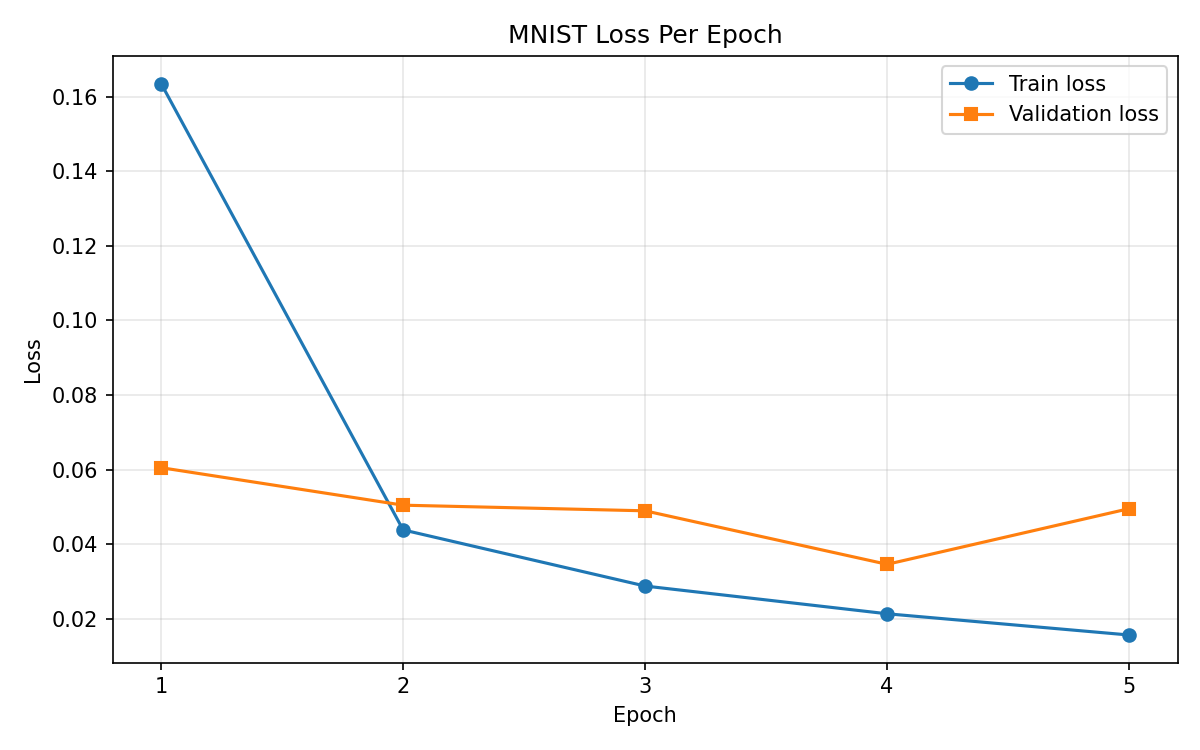

### loss_curve.png - with_augmentation


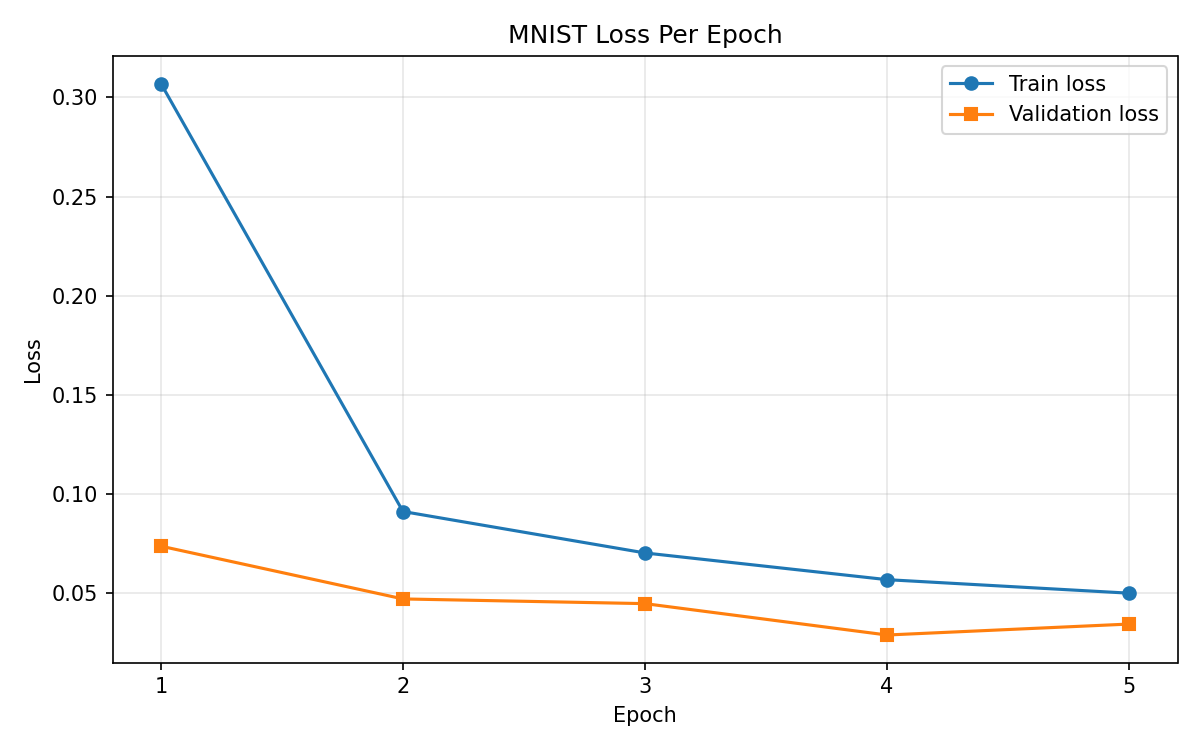


### accuracy_curve.png - without_augmentation


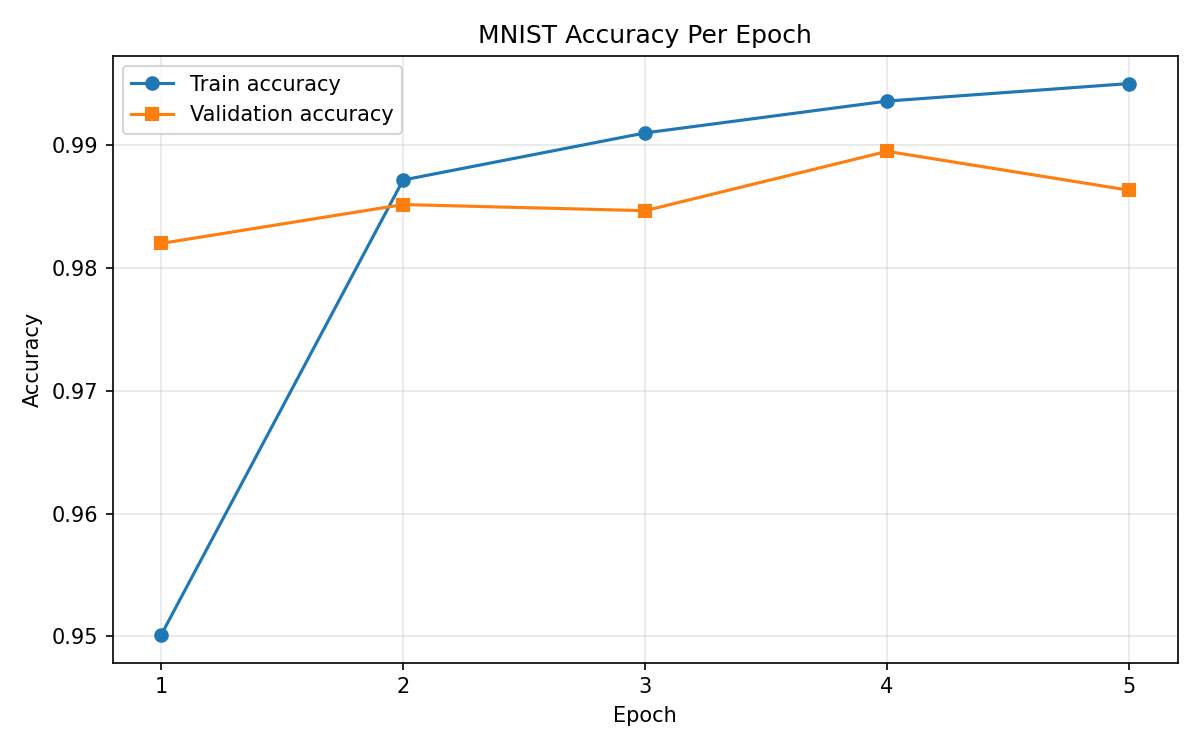

### accuracy_curve.png - with_augmentation


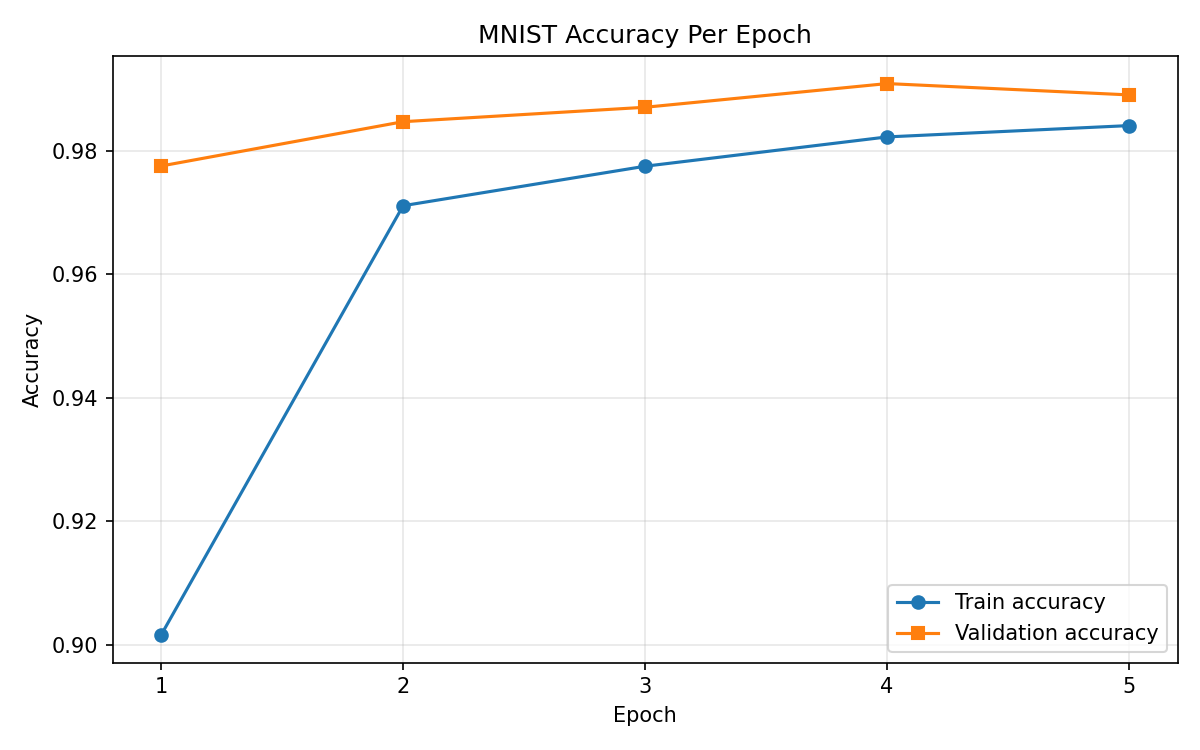


### confusion_matrix.png - without_augmentation


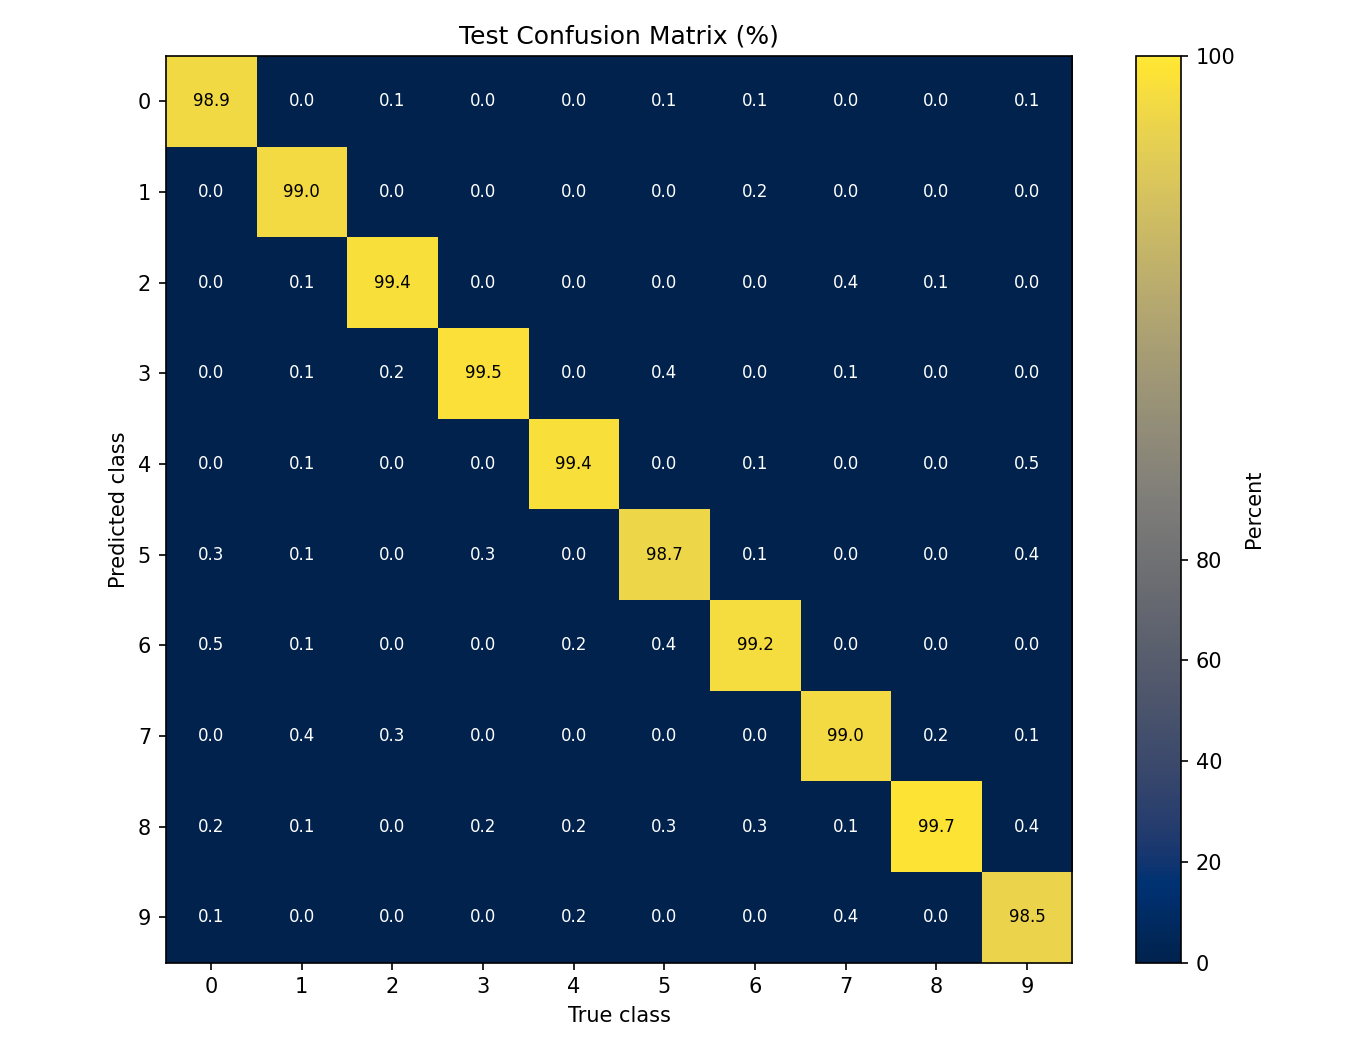

### confusion_matrix.png - with_augmentation


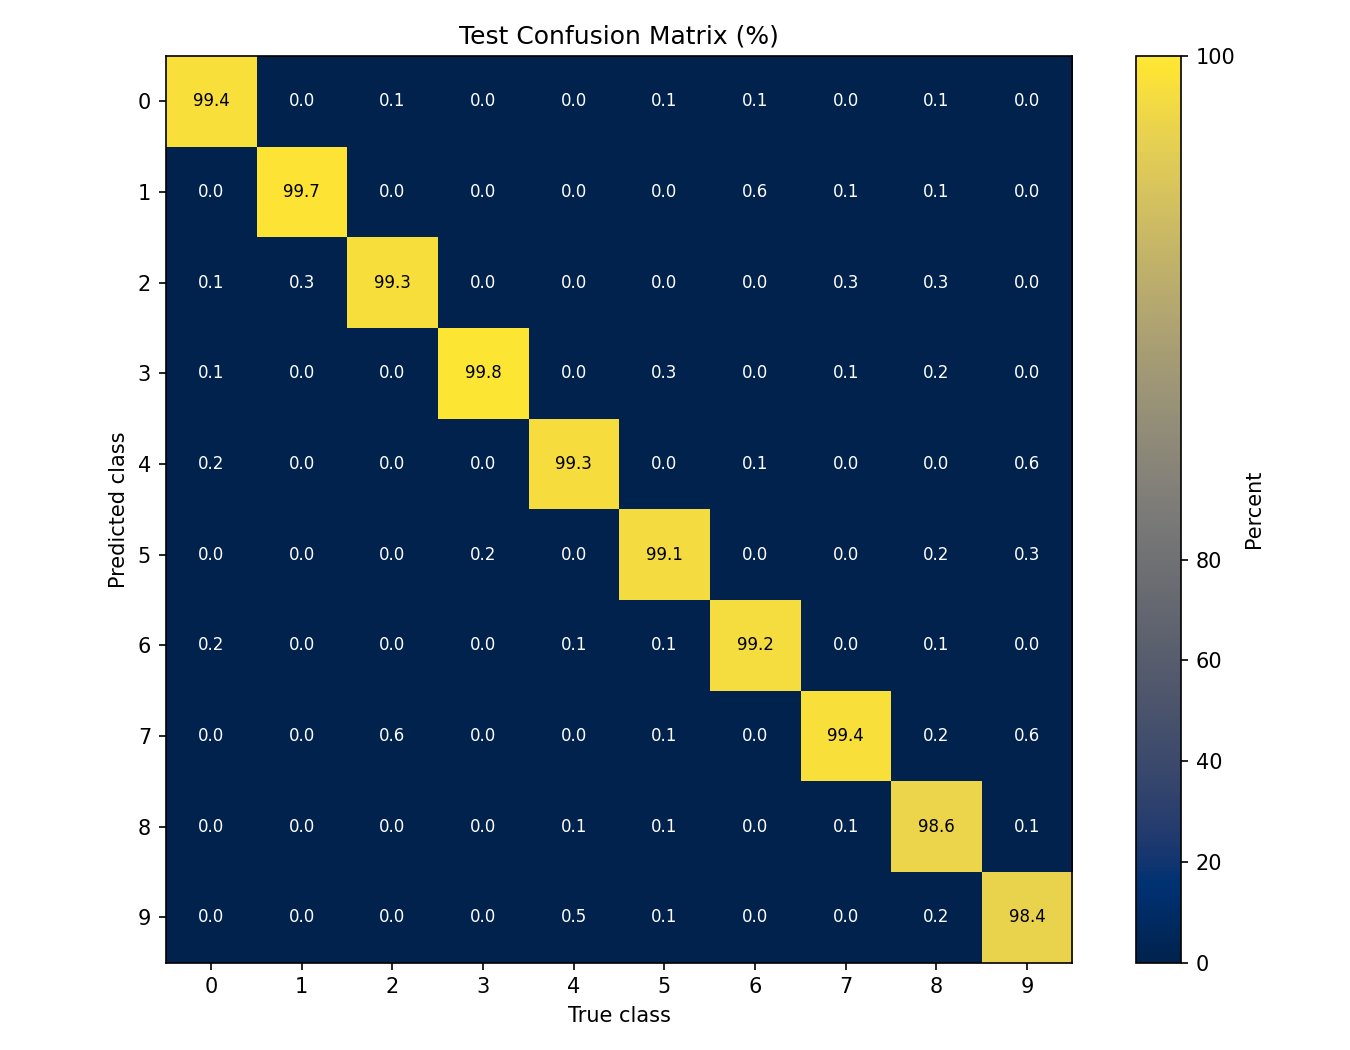


### correct_predictions.png - without_augmentation


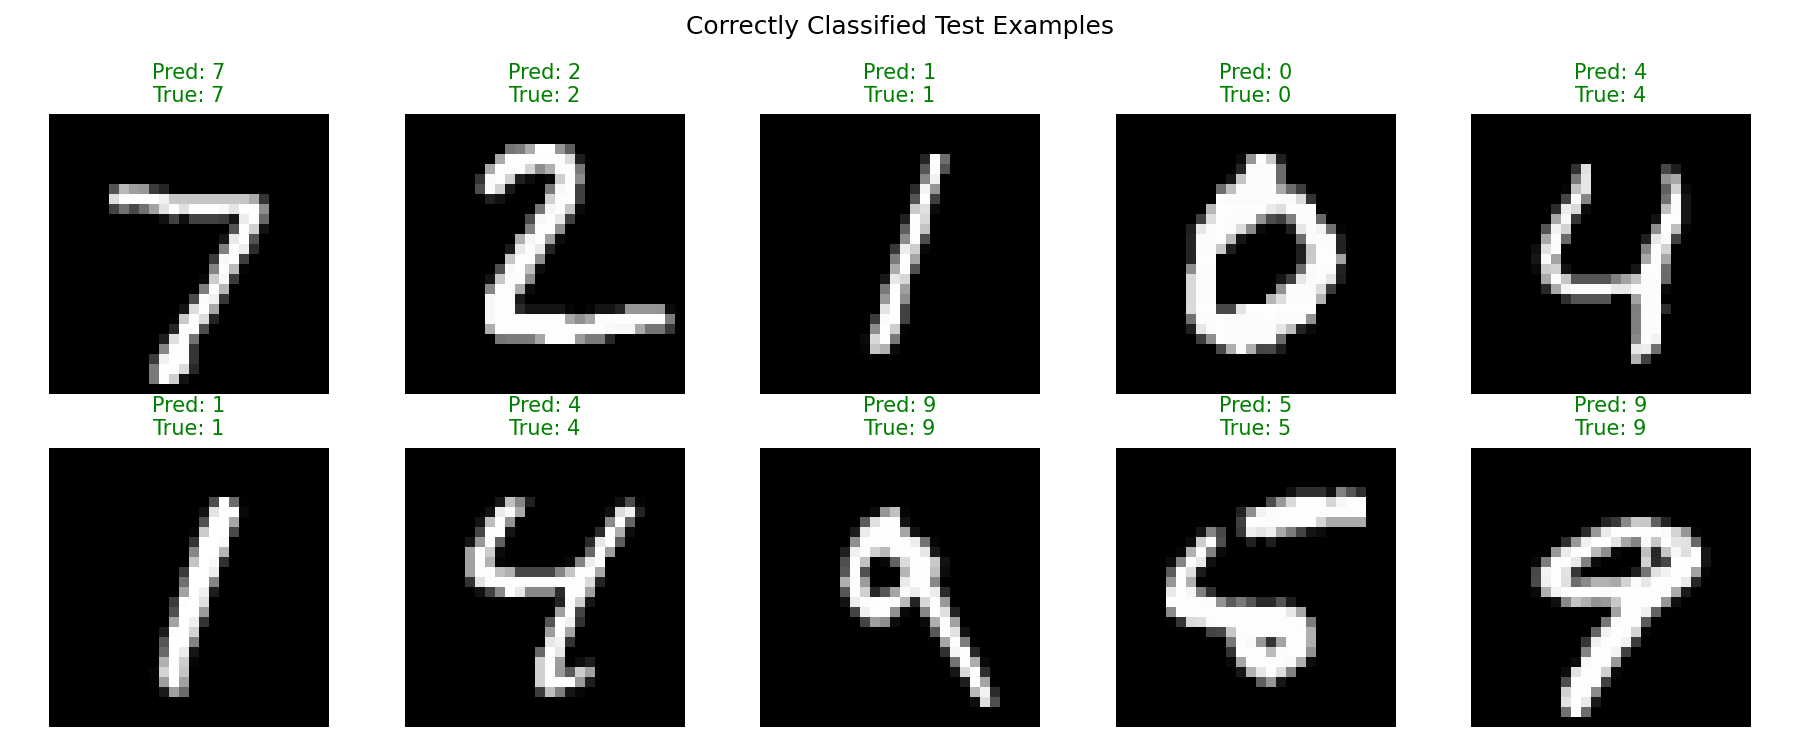

### correct_predictions.png - with_augmentation


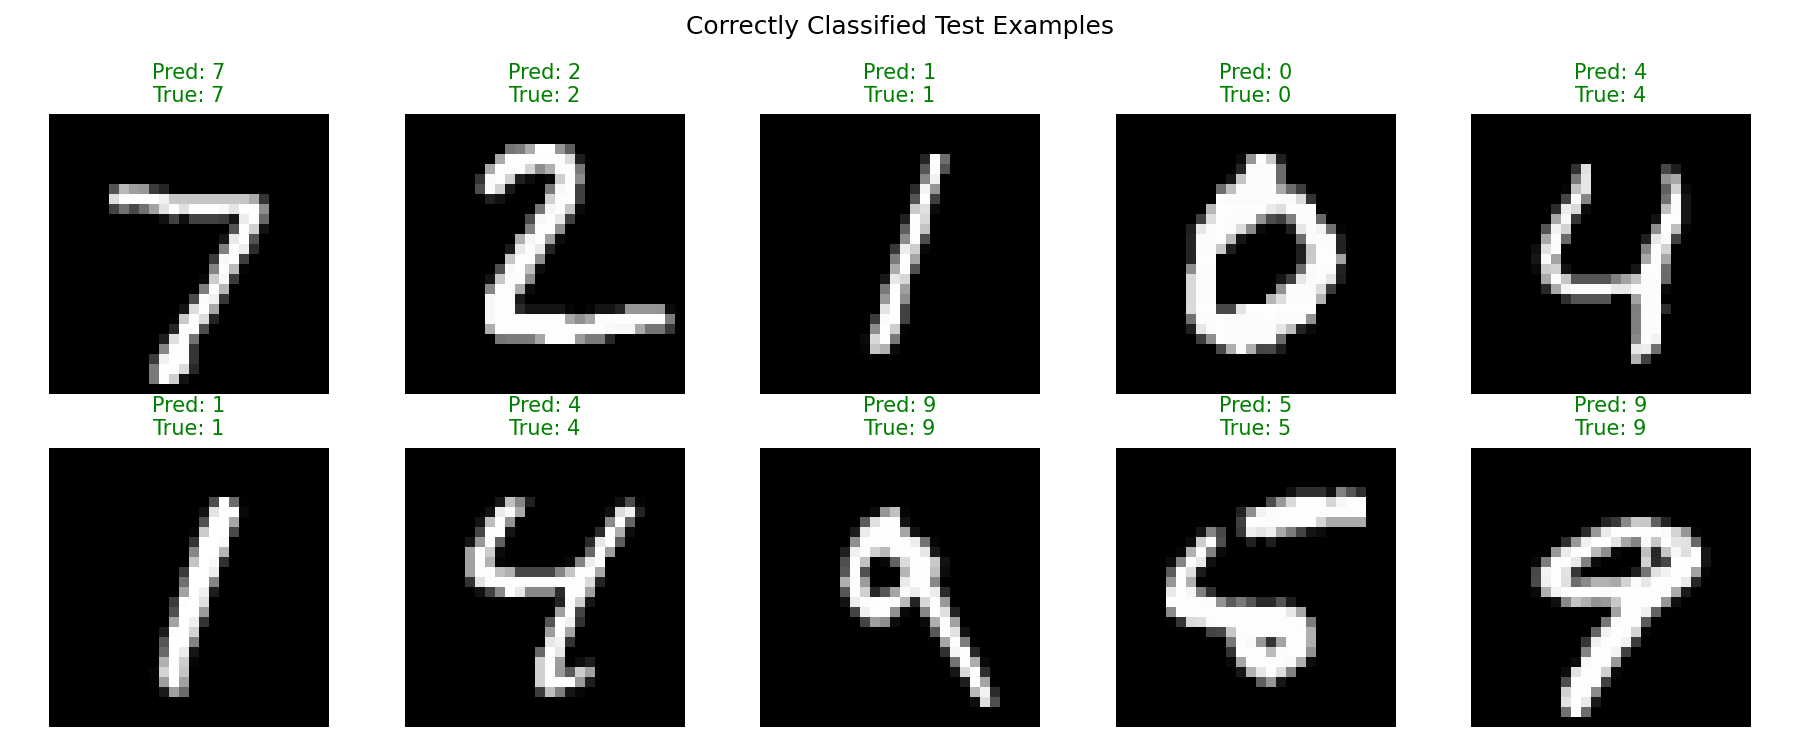


### incorrect_predictions.png - without_augmentation


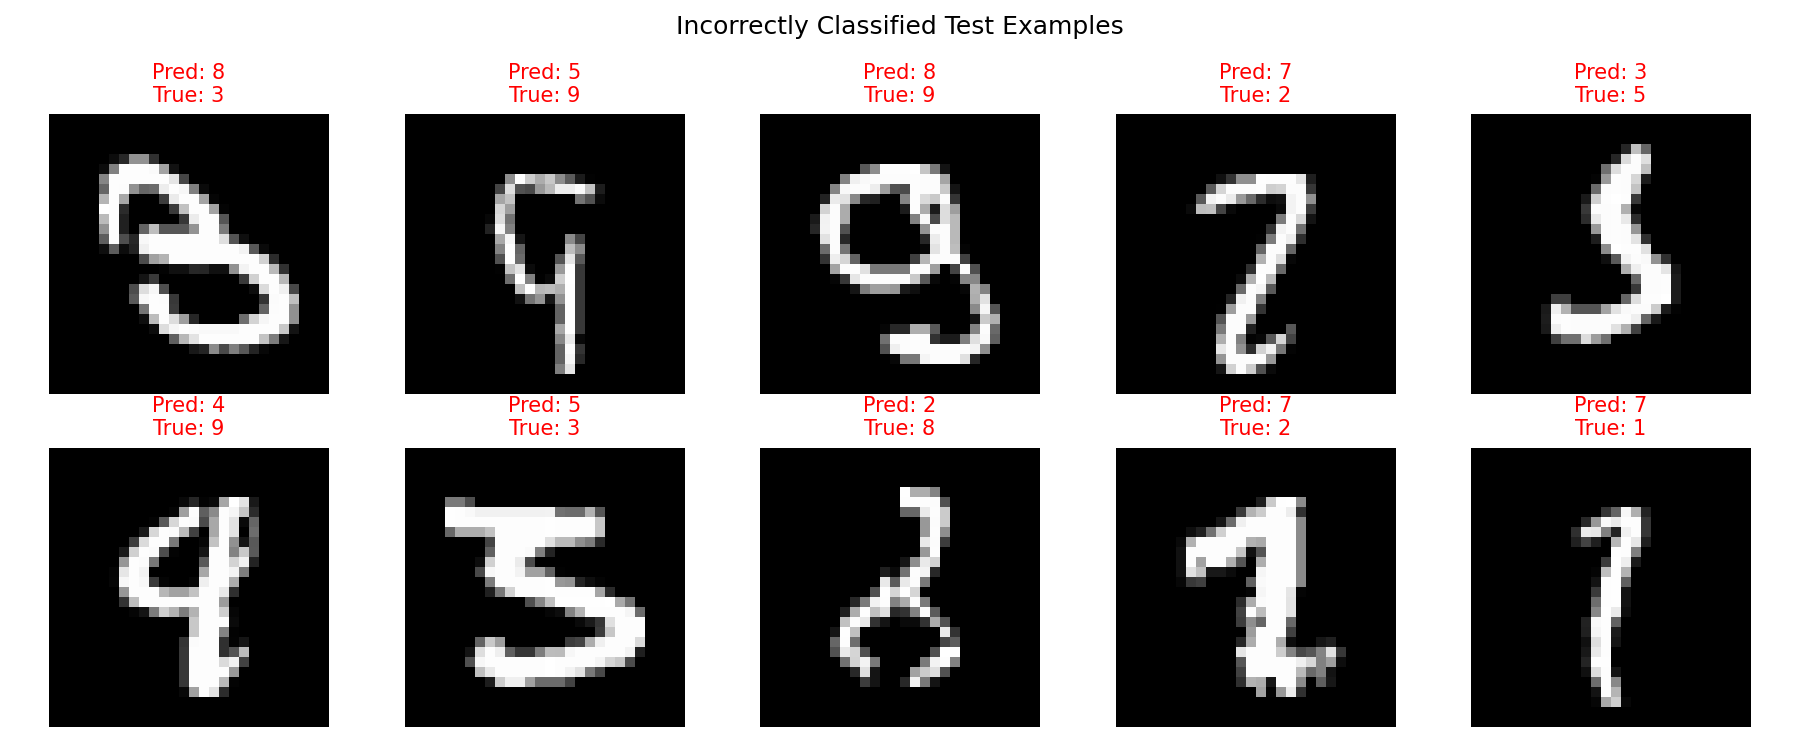

### incorrect_predictions.png - with_augmentation


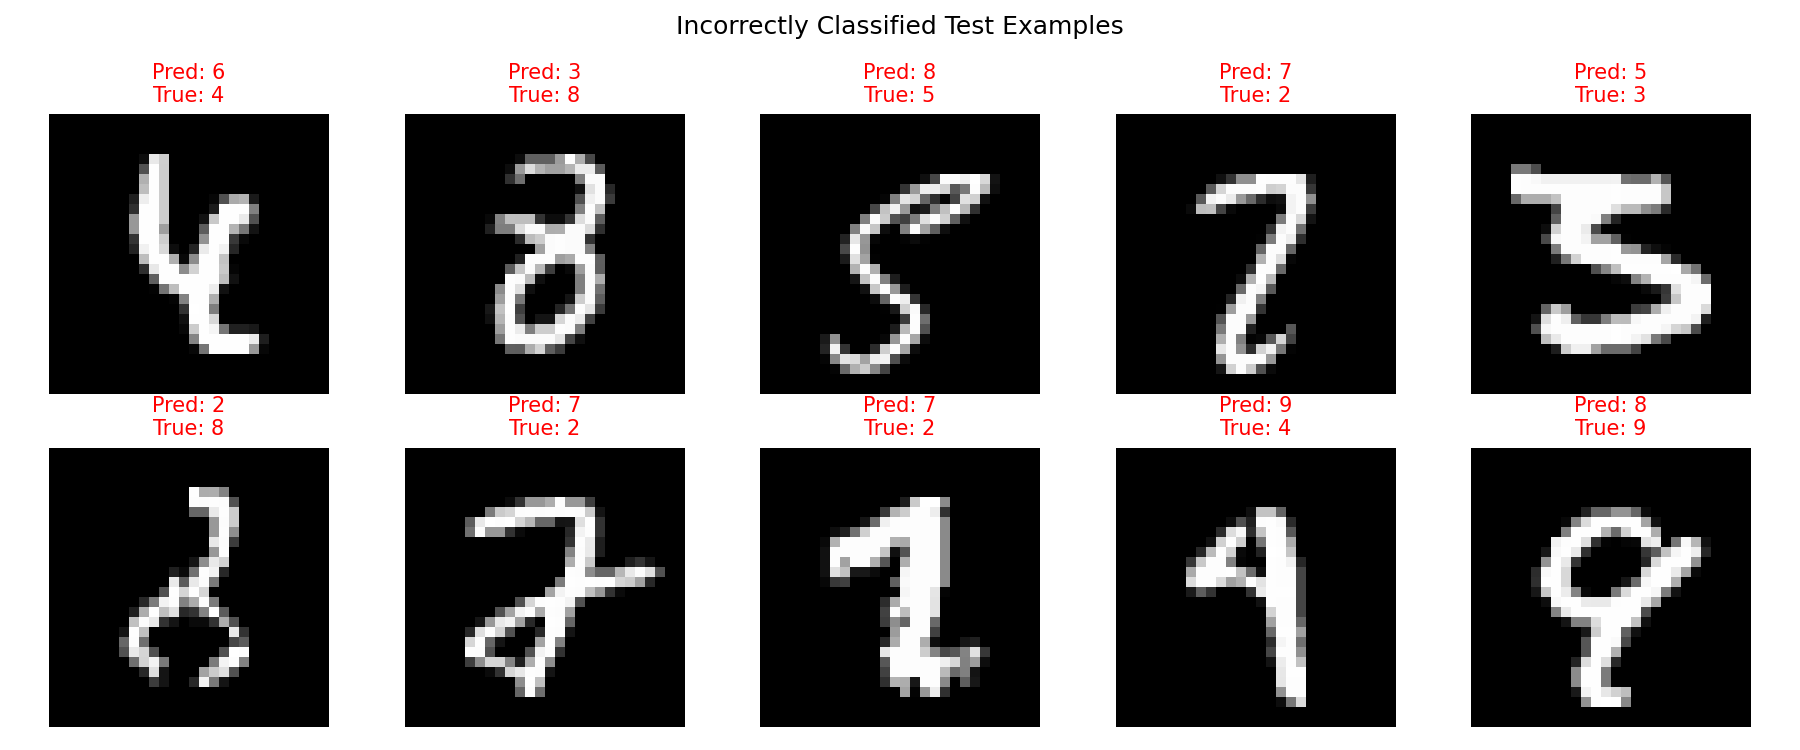

In [4]:
plot_files = [
    'loss_curve.png',
    'accuracy_curve.png',
    'confusion_matrix.png',
    'correct_predictions.png',
    'incorrect_predictions.png',
]

for plot_name in plot_files:
    print(f'\n### {plot_name} - without_augmentation')
    display(Image(filename=str(WITHOUT_RUN_DIR / plot_name)))
    print(f'### {plot_name} - with_augmentation')
    display(Image(filename=str(WITH_RUN_DIR / plot_name)))


## Training History

In [5]:
{
    'without_augmentation': without_history,
    'with_augmentation': with_history,
}

{'without_augmentation': {'train_loss': [0.16351924224529002,
   0.04383336095705077,
   0.028774938501210677,
   0.021336994710878503,
   0.015643261420549136],
  'train_accuracy': [0.9501111111111111,
   0.9871666666666666,
   0.991,
   0.9935925925925926,
   0.9950185185185185],
  'val_loss': [0.06051557185749213,
   0.050458805923660595,
   0.0489481641035527,
   0.03460201910013954,
   0.049525467799666024],
  'val_accuracy': [0.982,
   0.9851666666666666,
   0.9846666666666667,
   0.9895,
   0.9863333333333333],
  'epoch_duration_seconds': [7.564311899997847,
   7.269884400000592,
   7.515729400001874,
   7.4267412000008335,
   7.216563699999824]},
 'with_augmentation': {'train_loss': [0.30698274629204364,
   0.09113090772098965,
   0.0702249943393248,
   0.0567533833000257,
   0.049936980762967355],
  'train_accuracy': [0.9016296296296297,
   0.9710740740740741,
   0.977462962962963,
   0.9822037037037037,
   0.984037037037037],
  'val_loss': [0.07364837400615215,
   0.047034063

## Final Remark

In [6]:
test_acc_gap = (
    without_summary['final_test_accuracy']
    - with_summary['final_test_accuracy']
)
val_acc_gap = (
    without_summary['best_validation_accuracy']
    - with_summary['best_validation_accuracy']
)
val_loss_gap = (
    with_summary['best_validation_loss']
    - without_summary['best_validation_loss']
)
time_gap = (
    with_summary['total_training_time_seconds']
    - without_summary['total_training_time_seconds']
)

if test_acc_gap > 0:
    winner = 'without_augmentation'
elif test_acc_gap < 0:
    winner = 'with_augmentation'
else:
    winner = 'tie'

loss_winner = (
    'without_augmentation'
    if val_loss_gap > 0
    else 'with_augmentation'
    if val_loss_gap < 0
    else 'neither run'
)
time_winner = (
    'with_augmentation'
    if time_gap > 0
    else 'without_augmentation'
    if time_gap < 0
    else 'same runtime'
)

remark_lines = [
    f"Overall better run: {winner}",
    f"Test accuracy difference: {abs(test_acc_gap):.2%}",
    f"Best validation accuracy difference: {abs(val_acc_gap):.2%}",
    f"Best validation loss better for: {loss_winner}",
    f"Validation loss difference: {abs(val_loss_gap):.4f}",
    f"Training time difference: {abs(time_gap):.2f}s",
    f"Slower run: {time_winner}",
]
print('\n'.join(remark_lines))
remark_lines

Overall better run: with_augmentation
Test accuracy difference: 0.10%
Best validation accuracy difference: 0.13%
Best validation loss better for: with_augmentation
Validation loss difference: 0.0058
Training time difference: 12.91s
Slower run: with_augmentation


['Overall better run: with_augmentation',
 'Test accuracy difference: 0.10%',
 'Best validation accuracy difference: 0.13%',
 'Best validation loss better for: with_augmentation',
 'Validation loss difference: 0.0058',
 'Training time difference: 12.91s',
 'Slower run: with_augmentation']